In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/analyst_ratings_processed.csv
/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/raw_analyst_ratings.csv
/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/raw_partner_headlines.csv


In [2]:
df1=pd.read_csv("/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/analyst_ratings_processed.csv")
df2=pd.read_csv("/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/raw_analyst_ratings.csv")
df3=pd.read_csv("/kaggle/input/massive-stock-news-analysis-db-for-nlpbacktests/raw_partner_headlines.csv")

In [3]:
target_tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'GOOG', 
    'AVGO', 'ORCL', 'TSM', 'MRVL', 'ADBE', 'NFLX', 'TSLA'
]
df1_target=df1[df1['stock'].isin(target_tickers)].copy()

print(f"Original Dataset Size: {len(df1)} rows")
print(f"New Tech-Only Dataset: {len(df1_target)} rows")
df1_target

Original Dataset Size: 1400469 rows
New Tech-Only Dataset: 20421 rows


,Unnamed: 0,title,date,stock
3668,7120.0,Tech Stocks And FAANGS Strong Again To Start D...,2020-06-10 11:33:00-04:00,AAPL
3669,7121.0,10 Biggest Price Target Changes For Wednesday,2020-06-10 08:14:00-04:00,AAPL
3670,7122.0,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",2020-06-10 07:53:00-04:00,AAPL
3671,7123.0,"Deutsche Bank Maintains Buy on Apple, Raises P...",2020-06-10 07:19:00-04:00,AAPL
3672,7124.0,Apple To Let Users Trade In Their Mac Computer...,2020-06-10 06:27:00-04:00,AAPL
...,...,...,...,...
1251183,1264045.0,"Company News for January 08, 2010 - Corporate ...",2010-01-08 09:20:00-05:00,TSM
1251184,1264046.0,"Taiwan Semiconductor Manufacturing Co., Ltd. (...",2009-12-22 11:01:00-05:00,TSM
1251185,1264047.0,Deutsche (DB) Stays Conservative On Semi-condu...,2009-12-14 12:25:00-05:00,TSM
1251186,1264048.0,TSMC (TSM) Launches Automotive Process Qual...,2009-11-27 07:15:00-05:00,TSM


In [4]:
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from transformers import BertTokenizer


TARGET_STOCK = "AAPL"
START_DATE = "2012-01-01" 
END_DATE = "2020-06-11"   
WINDOW_SIZE = 30

print(f">> STEP 1: Grabbing {TARGET_STOCK} from your existing df1_target")



df_news = df1_target[df1_target['stock'] == TARGET_STOCK].copy()
df_news['date'] = pd.to_datetime(df_news['date'], utc=True).dt.date
df_grouped = df_news.groupby('date')['title'].apply(' '.join).reset_index()

print(f"Found {len(df_grouped)} days with news for {TARGET_STOCK}.")


print(f"\n>> STEP 2: Downloading Prices")

df_prices = yf.download(TARGET_STOCK, start=START_DATE, end=END_DATE)
df_prices.reset_index(inplace=True)

if isinstance(df_prices.columns, pd.MultiIndex):
    df_prices.columns = df_prices.columns.get_level_values(0)

df_prices['Date'] = pd.to_datetime(df_prices['Date']).dt.date


print(f"\n>> STEP 3: Merging & Labeling")

df_merged = pd.merge(df_prices, df_grouped, left_on='Date', right_on='date', how='left')
df_merged['title'] = df_merged['title'].fillna('market neutral trading')


df_merged['Next_Close'] = df_merged['Close'].shift(-1)
df_merged['Target'] = (df_merged['Next_Close'] > df_merged['Close']).astype(int)
df_merged.dropna(subset=['Next_Close'], inplace=True)


print(f"\n>> STEP 4: Tokenizing & Scaling")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_docs = tokenizer(
    df_merged['title'].tolist(),
    padding=True, truncation=True, max_length=50, return_tensors='np'
)


scaler = MinMaxScaler()
price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
scaled_prices = scaler.fit_transform(df_merged[price_cols])


print(f"\n>> STEP 5: Creating Sliding Windows")

def create_sequences(prices, input_ids, att_masks, y, win_size):
    X_p, X_id, X_mask, Y = [], [], [], []
    for i in range(win_size, len(prices)):
        X_p.append(prices[i-win_size:i])
        X_id.append(input_ids[i])
        X_mask.append(att_masks[i])
        Y.append(y.iloc[i])
    return np.array(X_p), np.array(X_id), np.array(X_mask), np.array(Y)

X_prices, X_ids, X_masks, y_train = create_sequences(
    scaled_prices, 
    encoded_docs['input_ids'], 
    encoded_docs['attention_mask'], 
    df_merged['Target'], 
    WINDOW_SIZE
)

print("\n Data Ready.")
print(f"Price Input Shape: {X_prices.shape}")
print(f"News Input Shape:  {X_ids.shape}")

>> STEP 1: Grabbing AAPL from your existing df1_target
Found 83 days with news for AAPL.

>> STEP 2: Downloading Prices


/tmp/ipykernel_24/2148620421.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_prices = yf.download(TARGET_STOCK, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed



>> STEP 3: Merging & Labeling

>> STEP 4: Tokenizing & Scaling


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


>> STEP 5: Creating Sliding Windows

 Data Ready.
Price Input Shape: (2092, 30, 5)
News Input Shape:  (2092, 50)


In [5]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from transformers import TFBertModel

# 1. Build the hybrid model architecture

def build_hybrid_model(price_shape, text_shape, bert_model_name='bert-base-uncased'):
    
    print(">> Loading Bert")
    
    bert = TFBertModel.from_pretrained(bert_model_name, use_safetensors=False)
    
    
    bert.trainable = False
    
    # BRANCH A: The "Quant" (Price History) ---
    price_input = Input(shape=price_shape, name='price_input')
    x_price = LSTM(64, return_sequences=True)(price_input) 
    x_price = Dropout(0.2)(x_price)                        
    x_price = LSTM(32, return_sequences=False)(x_price)    
    
    # Branch B: The "Analyst" (News Headlines)
    input_ids = Input(shape=text_shape, dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=text_shape, dtype=tf.int32, name='attention_mask')
    
    bert_output = bert(input_ids, attention_mask=attention_mask)[0][:, 0, :]
    
    # FUSION: Combine the two branches
    combined = concatenate([x_price, bert_output])
    
    
    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x) 
    
    model = Model(inputs=[price_input, input_ids, attention_mask], outputs=output)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Define input shapes
price_shape = (X_prices.shape[1], X_prices.shape[2]) 
text_shape = (X_ids.shape[1],)                       

print(">> Building Model")
model = build_hybrid_model(price_shape, text_shape)
model.summary()

# 2. TRAIN THE MODEL
print("\n>> Training")

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    [X_prices, X_ids, X_masks], 
    y_train,                    
    validation_split=0.2,       
    epochs=10,                  
    batch_size=32,
    callbacks=[early_stop]
)

print("\n>> Training is complete.")

2026-03-23 16:27:17.068893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774283237.244130      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774283237.295149      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774283237.710466      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774283237.710493      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774283237.710496      24 computation_placer.cc:177] computation placer alr

>> Building Model
>> Loading Bert


tf_model.h5:   0%|          | 0.00/536M [00:00<?, ?B/s]

I0000 00:00:1774283251.635071      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at bert-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 price_input (InputLayer)    [(None, 30, 5)]              0         []                            
                                                                                                  
 lstm (LSTM)                 (None, 30, 64)               17920     ['price_input[0][0]']         
                                                                                                  
 input_ids (InputLayer)      [(None, 50)]                 0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 50)]                 0         []                            
 )                                                                                            

I0000 00:00:1774283270.936161      84 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774283272.994315      85 service.cc:152] XLA service 0x7882a23c6d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774283272.994345      85 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774283273.240380      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


53/53 [==============================] - 25s 186ms/step - loss: 0.7194 - accuracy: 0.5140 - val_loss: 0.7053 - val_accuracy: 0.4535
Epoch 2/10
53/53 [==============================] - 6s 109ms/step - loss: 0.7033 - accuracy: 0.5152 - val_loss: 0.6977 - val_accuracy: 0.5251
Epoch 3/10
53/53 [==============================] - 6s 108ms/step - loss: 0.7035 - accuracy: 0.4871 - val_loss: 0.6929 - val_accuracy: 0.5274
Epoch 4/10
53/53 [==============================] - 5s 102ms/step - loss: 0.6953 - accuracy: 0.4895 - val_loss: 0.6947 - val_accuracy: 0.5251
Epoch 5/10
53/53 [==============================] - 5s 102ms/step - loss: 0.6936 - accuracy: 0.5129 - val_loss: 0.6955 - val_accuracy: 0.5251
Epoch 6/10
53/53 [==============================] - 5s 103ms/step - loss: 0.6951 - accuracy: 0.5057 - val_loss: 0.6954 - val_accuracy: 0.4487

>> Training is complete.


>> Predictions being generated
14/14 [==============================] - 5s 72ms/step
>> Running backtest simulator


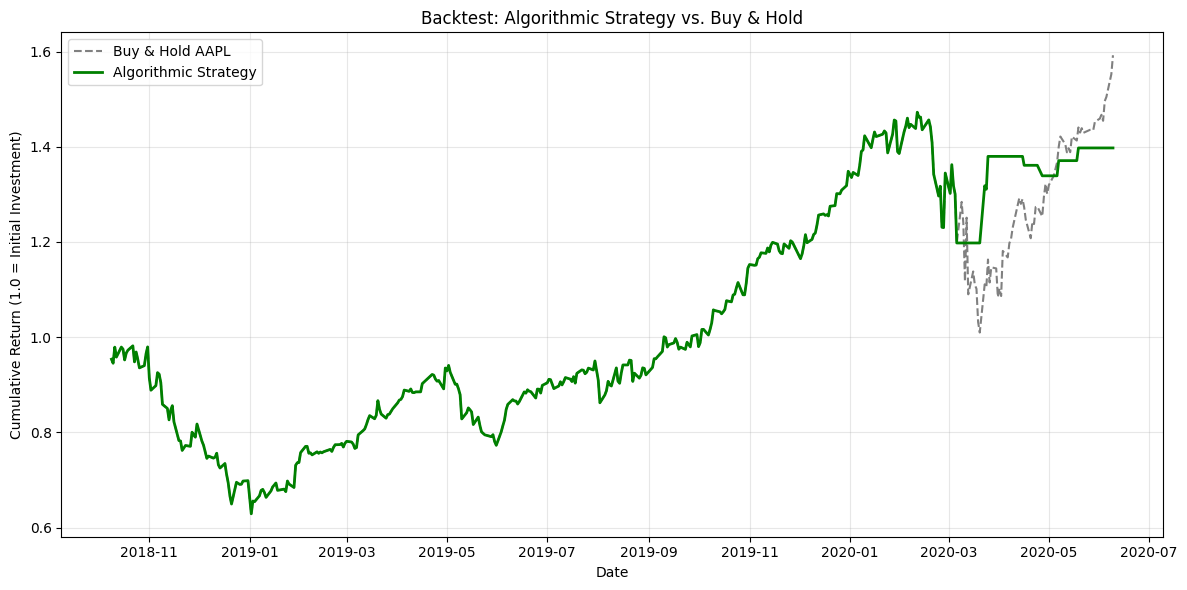

Total Return (Buy & Hold): 59.22%
Total Return (Algorithmic Strategy):  39.75%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print(">> Predictions being generated")


split_idx = int(len(X_prices) * 0.8)
X_val_prices = X_prices[split_idx:]
X_val_ids = X_ids[split_idx:]
X_val_masks = X_masks[split_idx:]

# Model predictions
preds_prob = model.predict([X_val_prices, X_val_ids, X_val_masks])

# Convert probabilities to hard decisions (1 = Buy, 0 = Sell)
preds_binary = (preds_prob > 0.5).astype(int)


print(">> Running backtest simulator")

val_start_index = WINDOW_SIZE + split_idx
df_val = df_merged.iloc[val_start_index:].copy()

# Add Model's Predictions to the DataFrame
df_val['Model_Prediction'] = preds_binary

# Calculate Daily Returns (Tomorrow's Close - Today's Close) / Today's Close
df_val['Daily_Return'] = (df_val['Next_Close'] - df_val['Close']) / df_val['Close']

# Calculate Strategy Returns
df_val['Strategy_Return'] = df_val['Daily_Return'] * df_val['Model_Prediction']

# Calculate Cumulative Returns (Compound Interest)
df_val['Buy_and_Hold_Cumulative'] = (1 + df_val['Daily_Return']).cumprod()
df_val['Strategy_Cumulative'] = (1 + df_val['Strategy_Return']).cumprod()

# --- Plotting the money chart---
plt.figure(figsize=(12, 6))
plt.plot(df_val['Date'], df_val['Buy_and_Hold_Cumulative'], label='Buy & Hold AAPL', color='gray', linestyle='--')
plt.plot(df_val['Date'], df_val['Strategy_Cumulative'], label='Algorithmic Strategy', color='green', linewidth=2)

plt.title('Backtest: Algorithmic Strategy vs. Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Initial Investment)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

bnh_final = (df_val['Buy_and_Hold_Cumulative'].iloc[-1] - 1) * 100
strat_final = (df_val['Strategy_Cumulative'].iloc[-1] - 1) * 100

print(f"Total Return (Buy & Hold): {bnh_final:.2f}%")
print(f"Total Return (Algorithmic Strategy):  {strat_final:.2f}%")

In [7]:
import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from transformers import BertTokenizer
import warnings


warnings.filterwarnings('ignore')


# Target List
target_tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 
    'AVGO', 'ORCL', 'TSM', 'MRVL', 'ADBE', 'NFLX', 'TSLA'
]
START_DATE = "2012-01-01" 
END_DATE = "2020-06-11"   
WINDOW_SIZE = 30

# Initialize the Tokenizer once
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


all_X_prices = []
all_X_ids = []
all_X_masks = []
all_y = []

print(f">> Starting multi-stock pipeline for {len(target_tickers)} stocks\n")


for ticker in target_tickers:
    print(f"--- Processing {ticker} ---")
    
    # 1. Grab News
    df_news = df1_target[df1_target['stock'] == ticker].copy()
    if df_news.empty:
        print(f"  -> Skipping: No news data found.")
        continue
        
    df_news['date'] = pd.to_datetime(df_news['date'], utc=True).dt.date
    df_grouped = df_news.groupby('date')['title'].apply(' '.join).reset_index()
    
    # 2. Download Prices
    
    df_prices = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if df_prices.empty:
        print(f" No price data found.")
        continue
        
    df_prices.reset_index(inplace=True)
    if isinstance(df_prices.columns, pd.MultiIndex):
        df_prices.columns = df_prices.columns.get_level_values(0)
    df_prices['Date'] = pd.to_datetime(df_prices['Date']).dt.date
    
    # 3. Merge & Label
    df_merged = pd.merge(df_prices, df_grouped, left_on='Date', right_on='date', how='left')
    df_merged['title'] = df_merged['title'].fillna('market neutral trading')
    
    df_merged['Next_Close'] = df_merged['Close'].shift(-1)
    df_merged['Target'] = (df_merged['Next_Close'] > df_merged['Close']).astype(int)
    df_merged.dropna(subset=['Next_Close'], inplace=True)
    
    # 4. Tokenize 
    encoded_docs = tokenizer(
        df_merged['title'].tolist(),
        padding='max_length', truncation=True, max_length=50, return_tensors='np'
    )
    
    # 5. Scale Prices 
    scaler = MinMaxScaler()
    price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    scaled_prices = scaler.fit_transform(df_merged[price_cols])
    
    # 6. Windowing
    for i in range(WINDOW_SIZE, len(scaled_prices)):
        all_X_prices.append(scaled_prices[i-WINDOW_SIZE:i])
        all_X_ids.append(encoded_docs['input_ids'][i])
        all_X_masks.append(encoded_docs['attention_mask'][i])
        all_y.append(df_merged['Target'].iloc[i])
        
    print(f" Successfully added {len(scaled_prices) - WINDOW_SIZE} sequences.")


#  Final Compilation

print("\n>> Stacking all data together.")
X_prices_master = np.array(all_X_prices)
X_ids_master = np.array(all_X_ids)
X_masks_master = np.array(all_X_masks)
y_master = np.array(all_y)

print("\n Sector dataset model is ready.")
print(f"Total Sequences (Rows): {X_prices_master.shape[0]}")
print(f"Price Input Shape:      {X_prices_master.shape}")
print(f"News Input Shape:       {X_ids_master.shape}")

>> Starting multi-stock pipeline for 12 stocks

--- Processing AAPL ---
 Successfully added 2092 sequences.
--- Processing MSFT ---
  -> Skipping: No news data found.
--- Processing NVDA ---
 Successfully added 2092 sequences.
--- Processing AMZN ---
 Successfully added 2092 sequences.
--- Processing GOOGL ---
 Successfully added 2092 sequences.
--- Processing AVGO ---
 Successfully added 2092 sequences.
--- Processing ORCL ---
 Successfully added 2092 sequences.
--- Processing TSM ---
 Successfully added 2092 sequences.
--- Processing MRVL ---
 Successfully added 2092 sequences.
--- Processing ADBE ---
 Successfully added 2092 sequences.
--- Processing NFLX ---
 Successfully added 2092 sequences.
--- Processing TSLA ---
 Successfully added 2092 sequences.

>> Stacking all data together.

 Sector dataset model is ready.
Total Sequences (Rows): 23012
Price Input Shape:      (23012, 30, 5)
News Input Shape:       (23012, 50)


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from transformers import TFBertModel
from sklearn.model_selection import train_test_split

print(">> 1. Shuffling and Splitting data")

X_p_train, X_p_val, X_i_train, X_i_val, X_m_train, X_m_val, y_train_split, y_val_split = train_test_split(
    X_prices_master, X_ids_master, X_masks_master, y_master, 
    test_size=0.2, 
    random_state=42
)

print(f"Training Samples: {len(y_train_split)}")
print(f"Validation Samples: {len(y_val_split)}")


# 2. Building the hybrid model

def build_hybrid_model(price_shape, text_shape, bert_model_name='bert-base-uncased'):
    print("\n>> 2. Constructing Model")
    bert = TFBertModel.from_pretrained(bert_model_name, use_safetensors=False)
    bert.trainable = False
    
    price_input = Input(shape=price_shape, name='price_input')
    x_price = LSTM(64, return_sequences=True)(price_input) 
    x_price = Dropout(0.2)(x_price)                        
    x_price = LSTM(32, return_sequences=False)(x_price)    
    
    input_ids = Input(shape=text_shape, dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=text_shape, dtype=tf.int32, name='attention_mask')
    
    bert_output = bert(input_ids, attention_mask=attention_mask)[0][:, 0, :]
    
    combined = concatenate([x_price, bert_output])
    
    x = Dense(64, activation='relu')(combined)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x) 
    
    model = Model(inputs=[price_input, input_ids, attention_mask], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

price_shape = (X_prices_master.shape[1], X_prices_master.shape[2]) 
text_shape = (X_ids_master.shape[1],)                       

sector_model = build_hybrid_model(price_shape, text_shape)

# 3. Model Training

print("\n>> 3. Model is being trained.")

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_sector = sector_model.fit(
    [X_p_train, X_i_train, X_m_train], 
    y_train_split,                    
    validation_data=([X_p_val, X_i_val, X_m_val], y_val_split),     
    epochs=10,                  
    batch_size=64,
    callbacks=[early_stop]
)

print("\n>> Training Completed.")

>> 1. Shuffling and Splitting data
Training Samples: 18409
Validation Samples: 4603

>> 2. Constructing Model


Some layers from the model checkpoint at bert-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at bert-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.



>> 3. Model is being trained.
Epoch 1/10
288/288 [==============================] - 69s 191ms/step - loss: 0.6985 - accuracy: 0.5080 - val_loss: 0.6931 - val_accuracy: 0.5162
Epoch 2/10
288/288 [==============================] - 51s 176ms/step - loss: 0.6921 - accuracy: 0.5234 - val_loss: 0.6931 - val_accuracy: 0.4995
Epoch 3/10
288/288 [==============================] - 51s 177ms/step - loss: 0.6925 - accuracy: 0.5246 - val_loss: 0.6924 - val_accuracy: 0.5166
Epoch 4/10
288/288 [==============================] - 51s 176ms/step - loss: 0.6916 - accuracy: 0.5262 - val_loss: 0.6928 - val_accuracy: 0.5168
Epoch 5/10
288/288 [==============================] - 51s 176ms/step - loss: 0.6918 - accuracy: 0.5265 - val_loss: 0.6924 - val_accuracy: 0.5164
Epoch 6/10
288/288 [==============================] - 51s 177ms/step - loss: 0.6914 - accuracy: 0.5271 - val_loss: 0.6921 - val_accuracy: 0.5164
Epoch 7/10
288/288 [==============================] - 50s 175ms/step - loss: 0.6913 - accuracy: 0.5